# ESA Biomass Level 1B COG georeferencing

The Level 1B data are distributed as cloud-optimized geotiffs (COGs) with ground control point (GCP) georeferencing instead of an affine transform. The data are georeferenced in this way because the amplitude values from the raw data correspond the radar geometry coordinates instead of a rectangular grid.

From the [Level 1a/b/c Product Specification](https://earth.esa.int/eogateway/documents/d/earth-online/biomass-level-1a-b-c-products-format-specification) description of the `ModelTiePointTag` GeoTIFF metadata tag:
> Maps image pixels to geographic coordinates, where N is the number of tie points in the scene, i.e.:
> - 5 tie points along range direction
> - 1 tie point each 10 seconds along azimuth direction
>
> Note: values have been computed in order to have an overall accuracy not worse than 100m (above ellipsoid).

Most applications and tools that can read COGs are able to use the GCPs to georeference the arrays but after reviewing the original data as well as reprojected arrays derived from the original data it became clear that the georeferencing does not yield a very good fit to physical features (e.g. river channels) from other Level 1b granules or external data sources.

The Look-Up Table (LUT) Annotation Data Set (ADS) NetCDF asset from each granule contains a 2D coordinate map that can be used to assign a precise latitude and longitude for each cell in the data array which can in turn be provided to tools like `rasterio` when reprojecting the source data to a rectangular grid in a 2D coordinate system (e.g. UTM zone bbox).

Here is a comparison of mapped river channels from three granules using both georeferencing approaches (GCP and LUT):

<img src="biomass-georeferencing-comparison.png" width="100%" alt="comparison of mapped river channels from three Biomass Level 1b granules">

Applications that wish to use the Level 1b for high-resolution mapping of physical characteristics may want to follow the approach for georeferencing the Level 1b data that is outlined in this notebook.

In [3]:
import os
from urllib.parse import urlsplit

import matplotlib.pyplot as plt
import numpy as np
import obstore as obs
import requests
import rasterio
import xarray as xr
from netCDF4 import Dataset
from obstore.store import HTTPStore
from pystac import Item
from pystac_client import Client
from rasterio.crs import CRS
from rasterio.enums import Resampling
from rasterio.transform import from_bounds
from rasterio.warp import reproject, transform_bounds
from shapely.geometry import box
from scipy.ndimage import map_coordinates
from xml.etree import ElementTree


STAC_API_URL = "https://catalog.maap.eo.esa.int/catalogue"
TOKEN_URL = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
POLARIZATIONS = ("HH", "HV", "VH", "VV")

## Setup

To demonstrate the georefencing situation I have picked a small area of interest that is covered by multiple Level 1b granules from June 2026. The accompanying Sentinel 2 granule will be used as "ground truth" for physical features on the landscape in the same time/place. To make it possible to compare the Biomass Level 1b data to the Sentinel 2 data, all sources will be projected to a UTM coordinate system with a 25 m resolution.

In [4]:
bbox = (108.06, 61.89, 108.16, 61.92)  # AOI covering a bend in a river
crs = CRS.from_string("EPSG:32649")  # approriate UTM zone for the AOI
target_resolution = 25

s2_stac_item_href = "https://earth-search.aws.element84.com/v1/collections/sentinel-2-c1-l2a/items/S2C_T49VCJ_20260611T041739_L2A"

Define a grid-aligned bounding box and affine transform for the target array in the UTM coordinate system

In [5]:
raw_bbox = transform_bounds("EPSG:4326", crs, *bbox)

grid_xmin = np.floor(raw_bbox[0] / target_resolution) * target_resolution
grid_ymin = np.floor(raw_bbox[1] / target_resolution) * target_resolution
grid_xmax = np.ceil(raw_bbox[2] / target_resolution) * target_resolution
grid_ymax = np.ceil(raw_bbox[3] / target_resolution) * target_resolution

target_bbox = (grid_xmin, grid_ymin, grid_xmax, grid_ymax)

target_width = int((grid_xmax - grid_xmin) / target_resolution)
target_height = int((grid_ymax - grid_ymin) / target_resolution)

target_transform = from_bounds(*target_bbox, target_width, target_height)

# coordinates for data arrays
x = target_transform.c + target_transform.a * (np.arange(target_width) + 0.5)
y = target_transform.f + target_transform.e * (np.arange(target_height) + 0.5)

print(target_height, target_width)
print(target_transform)

144 217
| 25.00, 0.00, 345475.00|
| 0.00,-25.00, 6868775.00|
| 0.00, 0.00, 1.00|


Load an array from the visual asset of a Sentinel 2 item (in the target transform)

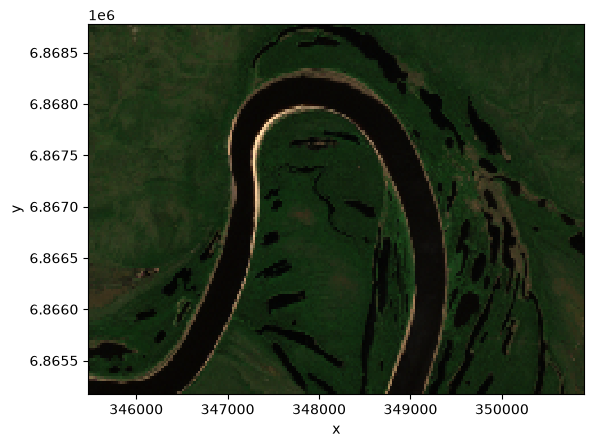

In [6]:
s2_item = Item.from_dict(requests.get(s2_stac_item_href).json())

with rasterio.Env(AWS_NO_SIGN_REQUEST=True):
    with rasterio.open(s2_item.assets["visual"].href) as src:
        s2 = np.full(
            (src.count, target_height, target_width),
            src.nodata,
            dtype=src.meta["dtype"],
        )

        reproject(
            source=rasterio.band(src, src.indexes),
            destination=s2,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=crs,
            resampling=Resampling.nearest,
        )

s2_da = xr.DataArray(
    s2,
    dims=("band", "y", "x"),
    coords={
        "band": ["red", "green", "blue"],
        "x": x,
        "y": y,
    },
    attrs={"crs": crs, "transform": tuple(target_transform)},
)
s2_da.plot.imshow()

The Sentinel 2 image will serve as the "ground truth" for physical features in the area of interest

Now conduct a STAC item search for Biomass Level 1b.

In [7]:
client = Client.open(STAC_API_URL)

search = client.search(
    collections="BiomassLevel1b",
    intersects=box(*bbox),
    datetime="2026-06-01T00:00:00Z/2026-06-12T00:00:00Z",
    sortby="datetime",
    max_items=6,
)

items = search.item_collection()
print(f"found {len(items)} items")
for item in items:
    print(item.id)

found 3 items
BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY
BIO_S3_DGM__1S_20260606T211626_20260606T211646_T_G01_M03_C01_T043_F056_02_DSMSWR
BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA


In [9]:
item.links

[<Link rel=self target=https://catalog.maap.eo.esa.int/catalogue/collections/BiomassLevel1b/items/BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA>,
 <Link rel=collection target=https://catalog.maap.eo.esa.int/catalogue/collections/BiomassLevel1b>,
 <Link rel=parent target=https://catalog.maap.eo.esa.int/catalogue/collections/BiomassLevel1b>,
 <Link rel=via target=https://catalog.maap.eo.esa.int/data/biomass-pdgs-01/BiomassLevel1b/2026/06/09/BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA/BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA/bio_s3_dgm__1s_20260609t211628_20260609t211648_t_g01_m03_c02_t043_f056_02_dsscxa.xml>,
 <Link rel=alternate target=https://catalog.maap.eo.esa.int/catalogue/collections/BiomassLevel1b/items/BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA?httpAccept=application/ld%2Bjson;profile=https://schema.org>,
 <Link rel=alternate target

The ESA assets require an auth token to read over HTTP. I have the required credentials stored in `ESA_MAAP_CLIENT_SECRET` and `ESA_OFFLINE_TOKEN` environment variables. See the [MAAP Docs](https://docs.maap-project.org/en/latest/science/ESA_BIOMASS/ESA_BIOMASS_Data_Access.html#Getting-the-ESA-MAAP-Long-Lasting-Token) for how to get these values from your ESA account.

In [10]:
client_secret = os.getenv("ESA_MAAP_CLIENT_SECRET")
offline_token = os.getenv("ESA_OFFLINE_TOKEN")


def request_access_token(client_secret: str, offline_token: str) -> str:
    """Exchange supplied MAAP credentials for an access token."""

    if not client_secret or not offline_token:
        raise ValueError("Missing MAAP credentials")

    response = requests.post(
        TOKEN_URL,
        data={
            "client_id": "offline-token",
            "client_secret": client_secret,
            "grant_type": "refresh_token",
            "refresh_token": offline_token,
            "scope": "offline_access openid",
        },
        timeout=60,
    )
    response.raise_for_status()
    token = response.json().get("access_token")

    if not token:
        raise RuntimeError("Failed to retrieve an access token from the IAM response")

    return token


token = request_access_token(client_secret, offline_token)

## Default behavior: use GCPs for georeferencing

By default, GIS software like GDAL will use the COG's GCPs for georeferencing the data. This works by assigning mapping specific pixels to a set of geographic coordinates in the specified CRS. `rasterio` defers the GCP transformation algorithm to GDAL which depends on the number of GCPs present. Most Biomass COGs have ~35 GCPs which results in a second order polynomial transformation.

The image below shows the GCPs for a COG plotted over the array.

![GCPs overlaid on Beta0 HH amplitude](./gcps.png)

The following code will read the AOI from the COG assets of each item and reproject it to the UTM CRS using the GCPs. The data are then stacked into an xarray `DataArray`.

In [15]:
with rasterio.Env(GDAL_HTTP_HEADERS=f"Authorization: Bearer {token}"):
    with rasterio.open(items[0].assets["enclosure_tiff"].href) as src:
        reprojected = np.full(
            (len(items), src.count, target_height, target_width),
            np.nan,
            dtype=src.meta["dtype"],
        )

    for i, item in enumerate(items):
        with rasterio.open(item.assets["enclosure_tiff"].href) as src:
            gcps, gcp_crs = src.gcps

            reproject(
                source=rasterio.band(src, src.indexes),
                destination=reprojected[i],
                gcps=gcps,
                src_crs=gcp_crs,
                dst_transform=target_transform,
                dst_crs=crs,
                resampling=Resampling.nearest,
                dst_nodata=np.nan,
            )

gcp_da = xr.DataArray(
    reprojected,
    dims=("id", "polarization", "y", "x"),
    coords={
        "id": [item.id for item in items],
        "polarization": list(POLARIZATIONS),
        "x": x,
        "y": y,
    },
    attrs={"crs": crs, "transform": tuple(target_transform)},
)

gcp_da

<xarray.DataArray (id: 3, polarization: 4, y: 144, x: 217)> Size: 1MB
array([[[[0.5639333 , 0.80540895, 0.92140895, ..., 0.80951613,
          1.0223662 , 1.0223662 ],
         [0.57900894, 0.750609  , 0.51440895, ..., 0.82751614,
          0.7001662 , 0.7139662 ],
         [0.49772182, 0.46620896, 0.35900897, ..., 1.0537663 ,
          0.88196623, 0.7797662 ],
         ...,
         [0.22935534, 0.19989721, 0.16669722, ..., 0.42479962,
          0.28759962, 0.35039866],
         [0.15469722, 0.17289722, 0.17469722, ..., 0.45439962,
          0.42759866, 0.57519865],
         [0.18129721, 0.14289722, 0.19449721, ..., 0.6237996 ,
          0.50199866, 0.44839865]],

        [[0.21324724, 0.17684141, 0.2066414 , ..., 0.26979604,
          0.4361771 , 0.4361771 ],
         [0.16824141, 0.18004142, 0.22244142, ..., 0.23199603,
          0.34357712, 0.3635771 ],
         [0.20353967, 0.14924142, 0.1996414 , ..., 0.3129771 ,
          0.22437711, 0.2635771 ],
...
          0.09188145, 0.11988145],
         [0.09707982, 0.08967982, 0.07627982, ..., 0.13973533,
          0.13488145, 0.12688145],
         [0.06967982, 0.07867982, 0.07647982, ..., 0.14713532,
          0.14713532, 0.14708145]],

        [[0.2701869 , 0.2243869 , 0.2475869 , ..., 0.574813  ,
          0.660413  , 0.6047118 ],
         [0.37138692, 0.4457869 , 0.3355869 , ..., 0.602813  ,
          0.517813  , 0.47611177],
         [0.4745869 , 0.6311869 , 0.4513869 , ..., 0.46921304,
          0.48581302, 0.43301302],
         ...,
         [0.11639768, 0.11061105, 0.10901105, ..., 0.48653516,
          0.5468614 , 0.5698614 ],
         [0.15421104, 0.13861105, 0.14361106, ..., 0.56813514,
          0.50786144, 0.39866143],
         [0.14461105, 0.14401105, 0.14641105, ..., 0.49433517,
          0.49433517, 0.31626144]]]],
      shape=(3, 4, 144, 217), dtype=float32)
Coordinates:
  * id            (id) <U80 960B 'BIO_S2_DGM__1S_20260601T121355_20260601T121...
  * polarization  (polarization) <U2 32B 'HH' 'HV' 'VH' 'VV'
  * y             (y) float64 1kB 6.869e+06 6.869e+06 ... 6.865e+06 6.865e+06
  * x             (x) float64 2kB 3.455e+05 3.455e+05 ... 3.509e+05 3.509e+05
Attributes:
    crs:        EPSG:32649
    transform:  (np.float64(25.0), np.float64(0.0), np.float64(345475.0), np....

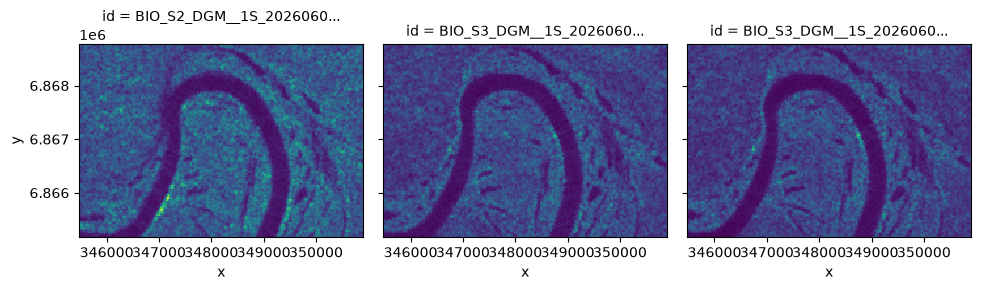

In [21]:
gcp_da.isel(polarization=0).plot.imshow(col="id", add_colorbar=False, add_labels=False)

When you look at each granule side by side, everything looks fine. However if you perform a composite image across granules, you can see that the river features are not located at the same coordinates across granules! Plotting the mean value of each pixel across all granules shows the geographic wobble of the river channel between granules.

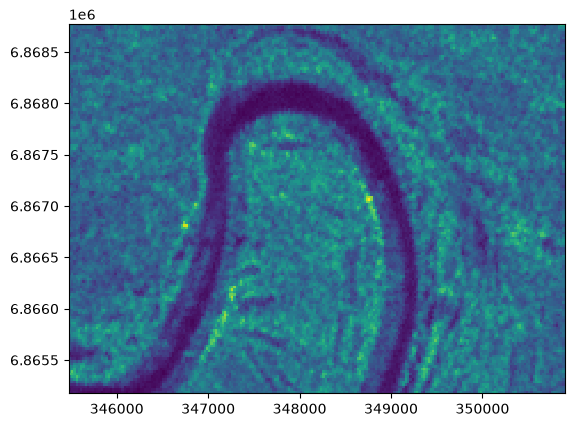

In [22]:
gcp_da.isel(polarization=0).mean(dim="id").plot.imshow(
    add_colorbar=False, add_labels=False
)

To highlight the river area as seen in the Biomass Level 1b data we can use a heuristic classification algorithm based on the values of the various polarizations.

In [32]:
def water_mask(da: xr.DataArray) -> xr.DataArray:
    water = (da.sel(polarization=["HH", "VV"]) < 0.30).all("polarization") & (
        da.sel(polarization=["HV", "VH"]) < 0.18
    ).all("polarization")

    return xr.where(water, 1, np.nan)


gcp_water_mask = water_mask(gcp_da)

The following image shows the pixels that are classified as water in pink and everything else transparent.

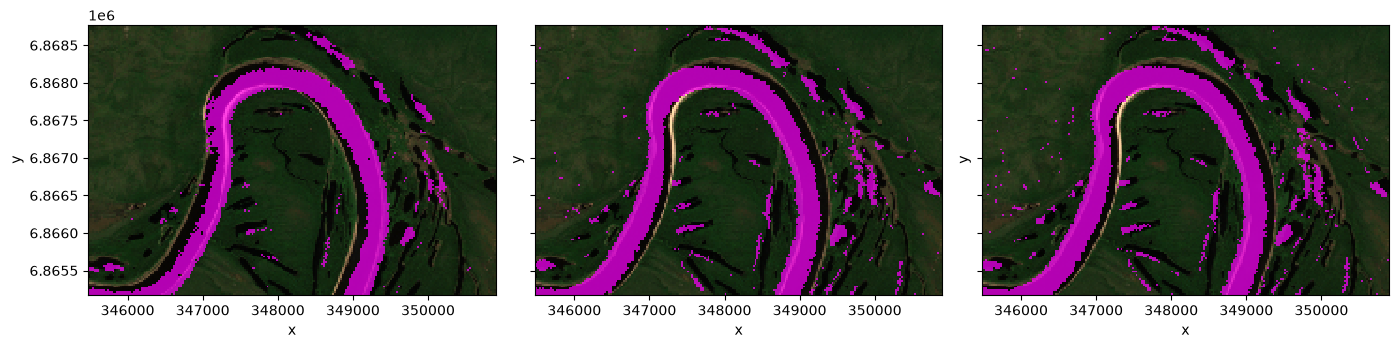

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), sharex=True, sharey=True)

for i, (item_id, ax) in enumerate(zip(gcp_da.id.values, axes)):
    s2_da.plot.imshow(rgb="band", ax=ax)

    gcp_water_mask.sel(id=item_id).plot.imshow(
        ax=ax,
        alpha=0.7,
        cmap="cool",
        vmin=0,
        vmax=1,
        add_colorbar=False,
        add_labels=False,
    )

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

Notice how the classified stream channel drifts from granule to granule. This suggests that the ~35 GCPs do not yield a very stable georeferencing solution from granule to granule. This is not entirely suprising given the stated accuracy target of "no worse than 100m".

## Optimized georeferencing: Use lat/lon coordinates from the Look-up Table NetCDF asset

The Level 1b data are accompanied by a Look-Up Table (LUT) NetCDF file that contains auxilliary information that can be used for radiometric terrain correction and other purposes. One of the groups of the hierarchical dataset includes an array of lat/lon coordinates that map to a grid of radar coordinates. This array is more dense than the GCPs in the COGs which yields a more precise georeferenced array after reprojection.

In [45]:
with rasterio.Env(GDAL_HTTP_HEADERS=f"Authorization: Bearer {token}"):
    with rasterio.open(items[0].assets["enclosure_tiff"].href) as src:
        reprojected = np.full(
            (len(items), src.count, target_height, target_width),
            np.nan,
            dtype=src.meta["dtype"],
        )

    for i, item in enumerate(items):
        # Fetch the LUT and annotation directly into memory.
        print(f"loading the LUT data for item {item.id}")
        asset_bytes = {}
        for key in ("enclosure_nc", "enclosure_annot_xml"):
            parsed_url = urlsplit(item.assets[key].href)
            store = HTTPStore(
                f"{parsed_url.scheme}://{parsed_url.netloc}",
                client_options={
                    "default_headers": {"Authorization": f"Bearer {token}"},
                    "timeout": "3m",
                },
            )
            response = await obs.get_async(store, parsed_url.path.lstrip("/"))
            asset_bytes[key] = bytes(await response.bytes_async())

        with Dataset(
            "geometry.nc", mode="r", memory=asset_bytes["enclosure_nc"]
        ) as lut:
            longitude_lut = np.asarray(lut["geometry/longitude"][:], dtype="float64")
            latitude_lut = np.asarray(lut["geometry/latitude"][:], dtype="float64")
            lut_azimuth = np.asarray(lut["relativeAzimuthTimeRGC"][:], dtype="float64")
            lut_slant_range = np.asarray(lut["slantRangeTimeRGC"][:], dtype="float64")
            print(
                f"found {len(longitude_lut)} longitude values and {len(latitude_lut)} latitude values"
            )

        sar_image = ElementTree.fromstring(asset_bytes["enclosure_annot_xml"]).find(
            "sarImage"
        )
        if sar_image is None:
            raise ValueError(f"{item.id}: annotation has no sarImage element")

        azimuth_interval = float(sar_image.findtext("azimuthTimeInterval"))
        range_pixel_spacing = float(sar_image.findtext("rangePixelSpacing"))
        ground_to_slant_coefficients = np.fromstring(
            sar_image.findtext(
                "rangeCoordinateConversion/coordinateConversion/"
                "groundToSlantCoefficients"
            ),
            sep=" ",
        )

        with rasterio.open(item.assets["enclosure_tiff"].href) as src:
            azimuth = np.arange(src.height, dtype="float64") * azimuth_interval
            slant_range = np.polynomial.polynomial.polyval(
                np.arange(src.width, dtype="float64") * range_pixel_spacing,
                ground_to_slant_coefficients,
            )
            if (
                azimuth[0] < lut_azimuth[0]
                or azimuth[-1] > lut_azimuth[-1]
                or slant_range[0] < lut_slant_range[0]
                or slant_range[-1] > lut_slant_range[-1]
            ):
                raise ValueError(f"{item.id}: Beta0 extent exceeds geometry LUT")

            lut_rows = np.interp(azimuth, lut_azimuth, np.arange(lut_azimuth.size))
            lut_columns = np.interp(
                slant_range, lut_slant_range, np.arange(lut_slant_range.size)
            )
            lut_row_grid, lut_column_grid = np.broadcast_arrays(
                lut_rows[:, np.newaxis],
                lut_columns[np.newaxis, :],
            )
            geolocation = tuple(
                map_coordinates(
                    values,
                    np.stack((lut_row_grid, lut_column_grid)),
                    order=1,
                    mode="nearest",
                    prefilter=False,
                )
                for values in (longitude_lut, latitude_lut)
            )

            reproject(
                source=rasterio.band(src, src.indexes),
                destination=reprojected[i],
                src_geoloc_array=geolocation,
                src_crs=CRS.from_string("EPSG:4326"),
                src_nodata=src.nodata,
                dst_transform=target_transform,
                dst_crs=crs,
                dst_nodata=np.nan,
                resampling=Resampling.nearest,
            )

lut_da = xr.DataArray(
    reprojected,
    dims=("id", "polarization", "y", "x"),
    coords={
        "id": [item.id for item in items],
        "polarization": list(POLARIZATIONS),
        "x": x,
        "y": y,
    },
    attrs={"crs": bbox, "transform": tuple(target_transform)},
)

lut_water_mask = water_mask(lut_da)

loading the LUT data for item BIO_S2_DGM__1S_20260601T121355_20260601T121415_T_G01_M03_C07_T008_F100_02_DSD6MY
found 2120 longitude values and 2120 latitude values
loading the LUT data for item BIO_S3_DGM__1S_20260606T211626_20260606T211646_T_G01_M03_C01_T043_F056_02_DSMSWR
found 2120 longitude values and 2120 latitude values
loading the LUT data for item BIO_S3_DGM__1S_20260609T211628_20260609T211648_T_G01_M03_C02_T043_F056_02_DSSCXA
found 2120 longitude values and 2120 latitude values


If we do the same composite operation with the arrays that use the LUT georeferencing method, we do not see the artifacts of poor geographic alignment across granules.

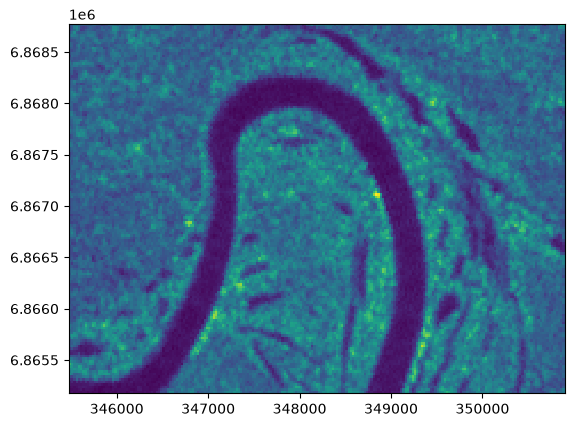

In [46]:
lut_da.isel(polarization=0).mean(dim="id").plot.imshow(
    add_colorbar=False, add_labels=False
)

When we plot the water mask we can see that the river channel lines up with the Sentinel 2 imagery much better than before.

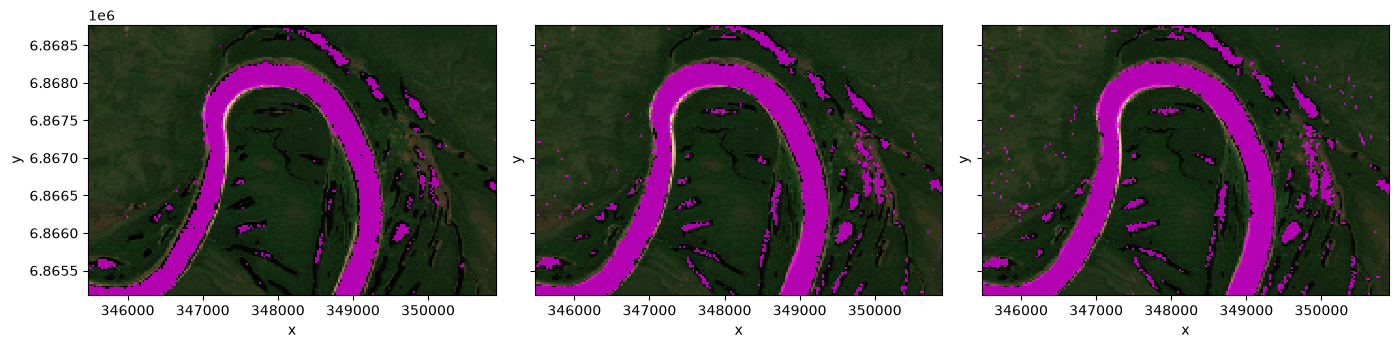

In [47]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6), sharex=True, sharey=True)

for i, (item_id, ax) in enumerate(zip(lut_da.id.values, axes)):
    s2_da.plot.imshow(rgb="band", ax=ax)

    lut_water_mask.sel(id=item_id).plot.imshow(
        ax=ax,
        alpha=0.7,
        cmap="cool",
        vmin=0,
        vmax=1,
        add_colorbar=False,
        add_labels=False,
    )

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

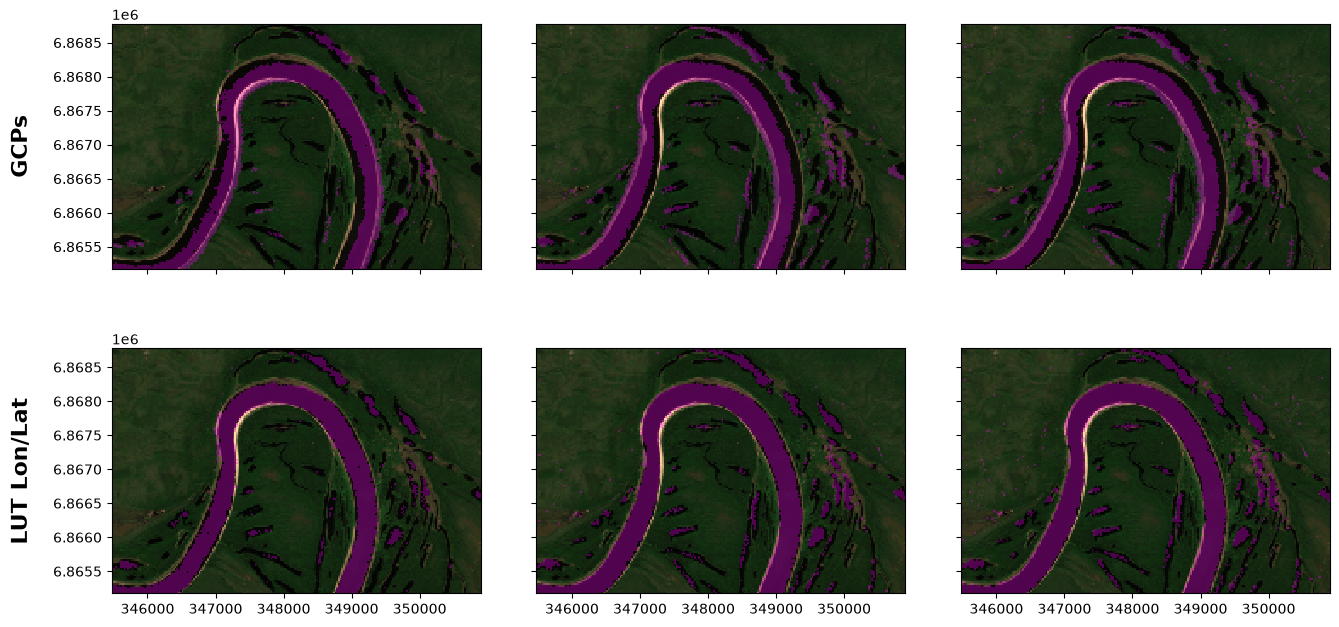

In [52]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7), sharex=True, sharey=True)
fig.subplots_adjust(
    left=0.08, right=0.95, bottom=0.05, top=0.90, hspace=0.2, wspace=0.15
)

row_labels = ["GCPs", "LUT Lon/Lat"]

for i, item_id in enumerate(gcp_da.id.values):
    ax_gcp = axes[0, i]  # Row 0 = GCPs
    ax_lut = axes[1, i]  # Row 1 = LUT Lon/Lat

    # ------------------ ROW 1: GCPs ------------------
    s2_da.plot.imshow(rgb="band", ax=ax_gcp)
    gcp_water_mask.sel(id=item_id).plot.imshow(
        ax=ax_gcp,
        alpha=0.3,
        cmap="cool",
        vmin=0,
        vmax=1,
        add_colorbar=False,
        add_labels=False,
    )
    ax_gcp.set_aspect("equal")

    # ------------------ ROW 2: LUT ------------------
    s2_da.plot.imshow(rgb="band", ax=ax_lut)
    lut_water_mask.sel(id=item_id).plot.imshow(
        ax=ax_lut,
        alpha=0.3,
        cmap="cool",
        vmin=0,
        vmax=1,
        add_colorbar=False,
        add_labels=False,
    )
    ax_lut.set_aspect("equal")

    for ax in [ax_gcp, ax_lut]:
        ax.set_ylabel("")
        ax.set_xlabel("")

axes[0, 0].set_ylabel(row_labels[0], fontsize=16, fontweight="bold", labelpad=15)
axes[1, 0].set_ylabel(row_labels[1], fontsize=16, fontweight="bold", labelpad=15)

plt.savefig("biomass-georeferencing-comparison.png")
plt.show()